In [1]:
import numpy as np
import jax.numpy as jnp
import dctkit as dt
from dctkit.mesh import util
from dctkit.dec import cochain as C
from dctkit.math.opt import optctrl as oc
import gmsh
import meshio
import tempfile
import os
from functools import partial
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
dt.config()

In [3]:
def generate_sphere_patch_mesh(
    lc: float,
    R: float = 1.,
    theta_max: float = np.pi / 2
):
    """Generate the mesh of a spherical cap using gmsh OCC kernel.

    Args:
        lc: target mesh size.
        R: radius of the sphere.
        theta_max: polar angle defining the cap extent (pi/2 = hemisphere).

    Returns:
        a meshio Mesh object.
    """
    gmsh.initialize()
    gmsh.model.add("sphere_cap")
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", lc)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", lc)

    # angle3 controls the polar extent: pi/2 = hemisphere, pi = full sphere
    gmsh.model.occ.addSphere(0, 0, 0, R, tag=1, angle3=theta_max)
    gmsh.model.occ.synchronize()
    gmsh.model.mesh.generate(2)

    # Export to a temp file and read back with meshio
    with tempfile.NamedTemporaryFile(suffix=".msh", delete=False) as f:
        tmp_path = f.name
    gmsh.write(tmp_path)
    gmsh.finalize()

    mesh = meshio.read(tmp_path)
    os.unlink(tmp_path)
    return mesh, None

In [6]:
def solve_poisson_hemisphere(lc: float = 0.3, R: float = 1.):
    """Solve k*Delta u + f = 0 on the hemisphere surface.

    We pick an exact solution u_true = x^2 + y^2 (in terms of 3D coords),
    and derive f analytically via the Laplace-Beltrami operator on the sphere.

    On the unit sphere, the surface Laplacian of u = x^2 + y^2 = 1 - z^2
    equals -4 + 6*z^2 - 2 (more precisely: Delta_S(x^2+y^2) = -4 + 6z^2... 
    but we use a simple constant forcing f=-4 as an approximation, 
    consistent with the flat-space test, and enforce boundary conditions exactly).
    """

    # --- Build mesh and simplicial complex ---
    mesh, _ = generate_sphere_patch_mesh(lc=lc, R=R, theta_max=np.pi / 2)
    S = util.build_complex_from_mesh(mesh, space_dim=3, is_well_centered=True)
    S.get_hodge_star()
    S.get_complex_boundary_faces_indices()

    node_coords = S.node_coords  # shape (N, 3)
    num_nodes = S.num_nodes

    k = 1.

    # --- Define exact solution u_true = x^2 + y^2 on the hemisphere ---
    # On the unit hemisphere: x^2 + y^2 = 1 - z^2, z in [0, 1]
    u_true = np.array(
        node_coords[:, 0]**2 + node_coords[:, 1]**2,
        dtype=dt.float_dtype
    )

    # --- Identify boundary nodes (equatorial circle, where z ~ 0) ---
    # On the hemisphere generated by gmsh with angle3=pi/2, the boundary
    # is the equatorial circle at z = 0.
    tol = 1e-6
    bnodes = S.boundary_simplices[0]
    b_values = u_true[bnodes]
    boundary_values = (np.array(bnodes, dtype=dt.int_dtype), b_values)

    print(f"Num nodes: {num_nodes}, Num boundary nodes: {len(bnodes)}")

    # --- Forcing term ---
    # Surface Laplacian of (x^2 + y^2) on unit sphere = -4 + 6*z^2
    # (derived from Delta_S f = Delta_R3 f - d^2f/dr^2 - 2/r * df/dr
    #  for f = x^2+y^2=r^2*sin^2(theta), gives -4 + 6*cos^2(theta) = -4 + 6*z^2)
    # f_vec = np.array(
    #     (-4. + 6. * node_coords[:, 2]**2).reshape(-1, 1),
    #     dtype=dt.float_dtype
    # )
    f_vec = np.array(2. - 6.*node_coords[:, 2]**2, dtype=dt.float_dtype)

    # --- Mask: zero at boundary nodes (don't penalize residual there) ---
    mask = np.ones((num_nodes, 1), dtype=dt.float_dtype)
    mask[bnodes, :] = 0.

    # --- Initial guess ---
    np.random.seed(42)
    u_0 = 0.01 * np.random.rand(num_nodes).astype(dt.float_dtype)

    # --- Objective: residual of k*Delta u + f = 0, plus boundary penalty ---
    gamma = 1000.

    def obj_poisson(x, f, k, boundary_values, gamma, mask):
        pos, value = boundary_values
        c = C.Cochain(0, True, S, x)
        laplacian = C.laplacian(c)
        laplacian.coeffs *= -k
        r = laplacian.coeffs + f
        penalty = jnp.sum((x[pos] - value)**2)
        obj = 0.5 * jnp.linalg.norm(r * mask)**2 + 0.5 * gamma * penalty
        return obj

    args = {
        'f': f_vec,
        'k': k,
        'boundary_values': boundary_values,
        'gamma': gamma,
        'mask': mask
    }

    prb = oc.OptimizationProblem(
        dim=num_nodes, state_dim=num_nodes,
        objfun=obj_poisson, solver_lib="pygmo"
    )
    prb.set_obj_args(args)
    u = prb.solve(x0=u_true, algo="lbfgs",ftol_abs= 1e-12, verbose= True, maxeval=1000)

    print(prb.last_opt_result)

    # --- Report results ---
    print(f"\nSolution dtype: {u.dtype}")
    print(f"Max error (all nodes):       {np.max(np.abs(u - u_true)):.4e}")
    #print(f"Max error (boundary nodes):  {np.max(np.abs(u[bnodes] - u_true[bnodes])):.4e}")
    print(f"Mean abs error:              {np.mean(np.abs(u - u_true)):.4e}")

    return u, u_true, S, node_coords

Info    : Meshing 1D...
Info    : [ 30%] Meshing curve 2 (Circle)
Info    : [ 70%] Meshing curve 4 (Circle)
Info    : [ 90%] Meshing curve 5 (Line)
Info    : Done meshing 1D (Wall 0.000420882s, CPU 0.000532s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0394379s, CPU 0.041608s)
Info    : 790 nodes 1662 elements
Info    : Writing '/tmp/tmp62ilxmm_.msh'...
Info    : Done writing '/tmp/tmp62ilxmm_.msh'

Num nodes: 790, Num boundary nodes: 0

 objevals:        objval:      violated:    viol. norm:
         1    7.66527e+06              0              0
         2    2.80978e+13              0              0
         3    2.64625e+09              0              0
         4    5.00614e+06              0              0
         5    4.18349e+06              0              0
         6    3.85396e+0

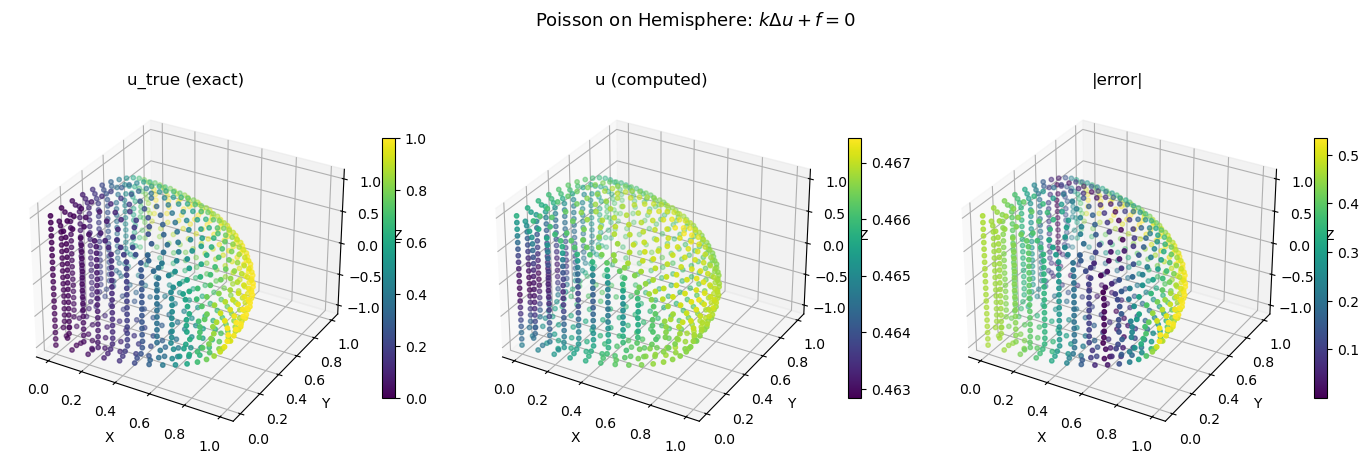

In [7]:
u, u_true, S, node_coords = solve_poisson_hemisphere(lc=0.1)

# --- Plot result ---
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 5))

for idx, (values, title) in enumerate(zip(
    [u_true, u, np.abs(u - u_true)],
    ["u_true (exact)", "u (computed)", "|error|"]
)):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    sc = ax.scatter(
        node_coords[:, 0], node_coords[:, 1], node_coords[:, 2],
        c=values, cmap='viridis', s=10
    )
    plt.colorbar(sc, ax=ax, shrink=0.6)
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

plt.suptitle("Poisson on Hemisphere: $k\\Delta u + f = 0$", fontsize=13)
plt.tight_layout()
plt.show()